<h1 style="font-size:40px;"><b>Mmakema Mokoana ST10537616</b></h1>
<h1 style="font-size:40px;"><b>Ice 2 : Exploratory Data Analysis</b></h1>
<h1 style="font-size:40px;"><b>Introduction to Linear Regression for Medical Aid Cost Prediction</b></h1>


______________________________________________________________________________________________________________________
______________________________________________________________________________________________________________________


The aim of this project is to develop a predictive model that estimates individual medical insurance charges based on demographic and lifestyle factors. These factors include age, sex, body mass index (BMI), number of children, smoking status, and region.

By analyzing the relationship between these variables and medical charges, the model seeks to provide accurate predictions that can support data-driven decision-making in areas such as insurance pricing.


______________________________________________________________________________________________________________________
______________________________________________________________________________________________________________________


Importing libraries and functions for the whole project. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Loading data from the csv file downloaded from kaggle.
The pandas library will be used to read the data. 

In [2]:
med_data = pd.read_csv("medicalinsurance.csv")

Next I am checking the structure and statistic of the data I have loaded. 
This will help me understand the data. 

In [3]:
#A preview of the first 5 rows of my dataframe to see how the data I am wotking with looks like
med_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains seven variables. Six of these variables — age, sex, BMI, number of children, smoking status, and region — are independent variables (also known as predictors or features). These variables are used to explain or predict the outcome.

The remaining variable, charges, is the dependent variable (target). It represents the medical insurance cost, which we aim to predict based on the independent variables.

In this project, I will build a model that learns the relationship between the predictors and the target variable in order to estimate medical charges for new data.


In [4]:
#The structure and summary statistics of the data

med_data.info()
med_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The dataset contains 1,338 observations, representing individual records included in the analysis. All seven variables have no missing (null) values, which means no data cleaning is required at this stage.
The age in the dataset ranges from 18 years to 64 years and the medical aid charges range from 1121.87 to 1121.48 currency units.

The dataset consists of both numerical and categorical variables, as shown in the summary output above. This distinction is important, as categorical variables will need to be encoded before they can be used in the model.

Based on this understanding of the data, the objective of this project is to predict medical charges. Therefore, the variable *charges* is defined as the target variable (y), while the remaining variables are treated as predictor variables (X).


In [5]:
# Defining my variables 

y = med_data["charges"]

X = med_data.drop("charges", axis=1)


<h1 style="font-size:40px;"><b>Data Preprocessing</b></h1>

The predictor variables (X) include categorical data types. In the next step, these non-numerical variables will be converted into numerical form, as machine learning models operate more effectively with numerical inputs.


In [6]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

In [7]:
#A preview of how my predictors look after the datatype conversion

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0


<h1 style="font-size:40px;"><b>Data Visualization and analysis</b></h1>

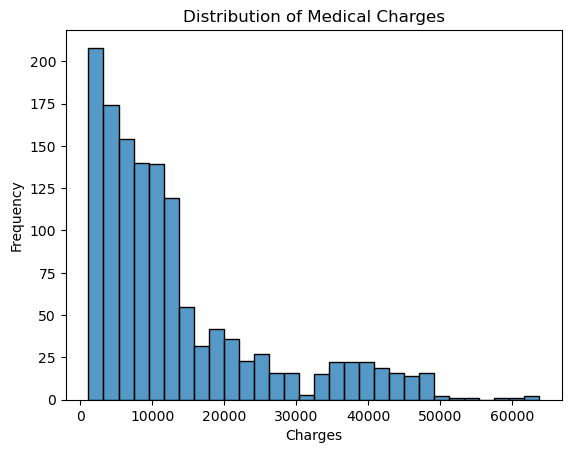

In [8]:
sns.histplot(med_data["charges"], bins=30)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

The distribution of medical charges is positively skewed (right-skewed), indicating that the majority of individuals incur relatively low to moderate medical costs, while a smaller number of individuals experience significantly higher charges.

This long right tail suggests the presence of high-cost outliers, which may be driven by factors such as smoking status or underlying health risks. The skewness shows that the data is not normally distributed.

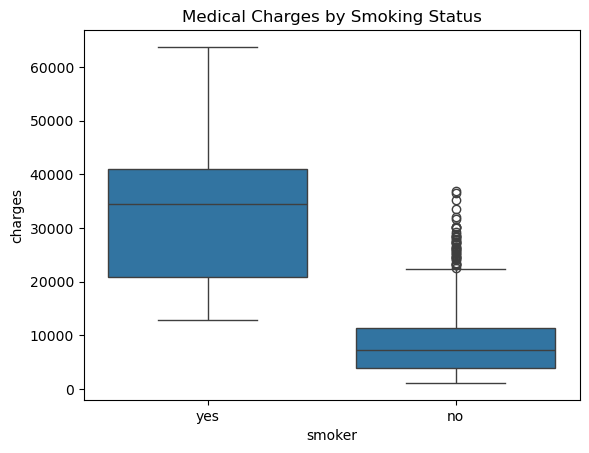

In [9]:
sns.boxplot(x="smoker", y="charges", data=med_data)
plt.title("Medical Charges by Smoking Status")
plt.show()

The boxplot reveals a significant difference in medical charges between smokers and non-smokers. Individuals who smoke incur substantially higher medical costs, with a much higher median and wider distribution compared to non-smokers.

Additionally, smokers exhibit greater variability in charges, indicating inconsistent but generally elevated costs. This suggests that smoking is a strong predictor of medical expenses and is likely one of the most influential variables in the model. The presence of outliers further indicates extreme cases of high medical costs within both groups, though they are more pronounced among smokers.


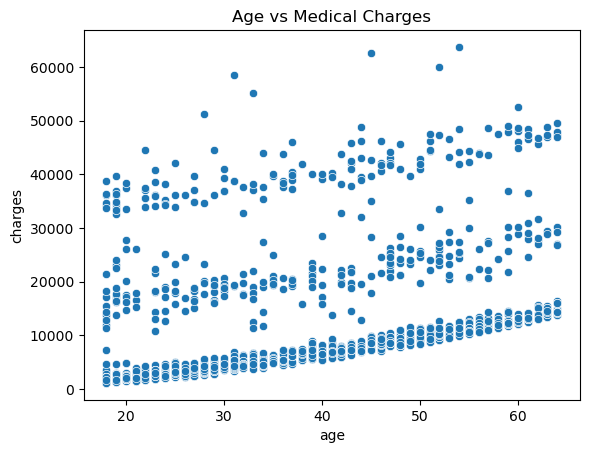

In [10]:
sns.scatterplot(x="age", y="charges", data=med_data)
plt.title("Age vs Medical Charges")
plt.show()

The scatter plot shows a positive relationship between age and medical charges, indicating that medical costs tend to increase as individuals get older. However, the relationship is not strictly linear, as there is noticeable variability in charges across all age groups.

The presence of distinct bands or clusters suggests that additional factors, such as smoking status, may be influencing the distribution of charges. This indicates that while age is an important predictor, it does not fully explain the variation in medical costs on its own.


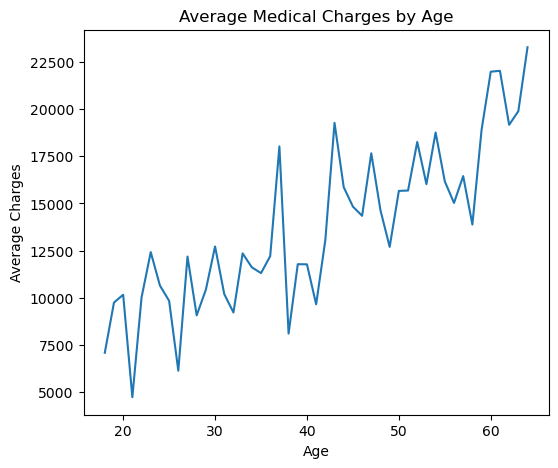

In [11]:
avg_data = med_data.groupby("age")["charges"].mean()

plt.figure(figsize=(6,5))

plt.plot(avg_data.index, avg_data.values)

plt.title("Average Medical Charges by Age")
plt.xlabel("Age")
plt.ylabel("Average Charges")

plt.show()

Charges and age has a positive non linear relationship. We see and increase in average medical aid charges as the age goes up but the charges have a lit of variance which can be explained by other factors including smoking, BMI and number of kids.  This also means there are outliers in the data that are influencing this variation. 

____________________________________________________________________________________________________________________________________________________
____________________________________________________________________________________________________________________________________________________

<h1 style="font-size:40px;"><b>Linear Regression Model Training</b></h1>

In the next step, the dataset is split into training and testing subsets using a function from the scikit-learn library. 
Eighty percent of the data is allocated to the training set, which is used to train the model, while the remaining twenty percent is reserved as the test set to evaluate the model’s performance on unseen data.


In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear regression  is an sk learn function and we will use it to fit the training data. 

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
print(model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

-11727.116859614709


,Feature,Coefficient
0,age,257.095630
1,bmi,335.631168
2,children,427.577700
3,sex_male,-17.293071
4,smoker_yes,23655.694331
5,region_northwest,-364.168891
6,region_southeast,-667.600806
7,region_southwest,-819.601443


The linear regression model indicates that smoking status is the most significant predictor of medical charges, with smokers incurring substantially higher costs compared to non-smokers. Specifically, being a smoker increases predicted medical charges by approximately 23,656 units, holding all other variables constant.
It makes sense for sokers to have high charges as smoking can positively contribute to a lot of health problems including cancer, TB and cardiac problems. These are often chronic and expensive to treat and heal. 

Age and BMI also show positive relationships with medical charges, suggesting that older individuals and those with higher BMI tend to have higher medical expenses. The number of children has a moderate positive effect, while gender has a negligible impact on charges.

Regional differences appear to have a relatively small influence on medical costs when compared to other variables. Overall, the model highlights that lifestyle factors, particularly smoking, play a critical role in determining medical insurance charges.


In [15]:
predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

R2 Score: 0.7837881278275863
MSE: 33566618.8882287
RMSE: 5793.670588515428


The model achieved an R-squared value of ~0.78, indicating that approximately 78% of the variability in medical charges is explained by the predictor variables. This suggests that the model has a strong ability to capture the underlying relationships in the data.

The mean squared error (MSE) measures the average squared difference between the predicted and actual values. To provide a more interpretable measure, the root mean squared error (RMSE) was calculated as approximately 5,794. This indicates that, on average, the model’s predictions deviate from the actual medical charges by about 5,794 currency units. 


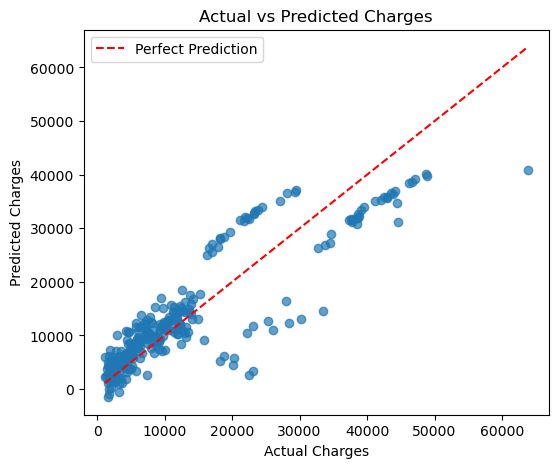

In [16]:
plt.figure(figsize=(6,5))

# Scatter plot
plt.scatter(y_test, predictions, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linestyle="--", label="Perfect Prediction"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.legend()

plt.show()

__________________________________________________________________________________________________________________________________

The whole analysis indicates that smoking status is the most influential factor affecting medical insurance charges, as smokers consistently incur significantly higher costs than non-smokers. Age also shows a positive relationship with charges, suggesting that medical expenses tend to increase as individuals get older, while BMI has a moderate impact on costs.

Smoking likely affects insurance costs due to its association with increased health risks and a higher likelihood of requiring medical treatment. As a result, insurers assign higher charges to individuals who smoke.

To improve the model, additional variables such as medical history, lifestyle habits, or income level could be included. Furthermore, more advanced models could be explored to capture non-linear relationships and improve predictive performance.


<h1 style="font-size:40px;"><b>Conclusion</b></h1>

In conclusion, this project successfully developed a linear regression model to predict medical insurance charges using demographic and lifestyle variables. The analysis demonstrated that smoking status is the most significant predictor of medical costs, with smokers incurring substantially higher charges than non-smokers. Additional factors such as age and BMI were also found to contribute to the variation in charges.

The model achieved a strong R-squared value of ~0.78, indicating that it explains a large proportion of the variability in the target variable. While the model provides reasonably accurate predictions, the presence of prediction error suggests that other factors not included in the dataset may influence medical costs.

Overall, this project highlights the importance of data preprocessing, exploratory data analysis, and model evaluation in building effective predictive models. It also demonstrates how data-driven insights can be used to better understand the key drivers of real-world outcomes such as medical expenses.

